# Imports and Definitions

In [1]:
import astropy.io.fits as fits
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

from scipy import stats
from scipy.signal import find_peaks
from matplotlib.colors import Normalize
from scipy.ndimage import rotate
from scipy.optimize import minimize
from scipy.optimize import curve_fit
from astropy.io.fits import getdata

In [2]:
import importlib
import grism_utils_v2
importlib.reload(grism_utils_v2)
from grism_utils_v2 import spectrum

/Users/joshuamarine/Desktop/Code/Be-Stars/grism_utils_v2.py:1650: SyntaxWarning: invalid escape sequence '\g'
  ("O$_2$ $\gamma$ band" in str(lbl))


In [3]:
def fit_gaussian_fwhm(
    x,
    y,
    x0,
    window=30,
    absorption=True,
    lin_bkg=True,
    plot=True
):
    """
    Fit a Gaussian near x0 and measure FWHM.

    Parameters
    ----------
    x, y : arrays
        Spectrum x/y arrays.
    x0 : float
        Approximate line center.
    window : float
        Half-width around x0 to fit.
    absorption : bool
        True for absorption line, False for emission.
    lin_bkg : bool
        Use linear background instead of constant.
    plot : bool
        Plot result.

    Returns
    -------
    dict
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = (x >= x0 - window) & (x <= x0 + window)
    xfit = x[mask]
    yfit = y[mask]

    if len(xfit) < 5:
        raise ValueError("Fit window contains too few points.")

    # ----------------------------
    # Model definitions
    # ----------------------------
    if lin_bkg:
        def model(x, amp, mu, sigma, m, b):
            return m*x + b + amp * np.exp(-0.5 * ((x - mu) / sigma)**2)
    else:
        def model(x, amp, mu, sigma, c):
            return c + amp * np.exp(-0.5 * ((x - mu) / sigma)**2)

    # ----------------------------
    # Initial guesses
    # ----------------------------
    c0 = np.nanmedian(yfit)

    if absorption:
        amp0 = np.nanmin(yfit) - c0
        mu0 = xfit[np.nanargmin(yfit)]
    else:
        amp0 = np.nanmax(yfit) - c0
        mu0 = xfit[np.nanargmax(yfit)]

    sigma0 = window / 5

    if lin_bkg:
        m0 = 0.0
        b0 = c0
        p0 = [amp0, mu0, sigma0, m0, b0]
        bounds = (
            [-np.inf, xfit.min(), 0, -np.inf, -np.inf],
            [ np.inf, xfit.max(), np.inf,  np.inf,  np.inf]
        )
    else:
        p0 = [amp0, mu0, sigma0, c0]
        bounds = (
            [-np.inf, xfit.min(), 0, -np.inf],
            [ np.inf, xfit.max(), np.inf,  np.inf]
        )

    # ----------------------------
    # Fit
    # ----------------------------
    popt, pcov = curve_fit(
        model,
        xfit,
        yfit,
        p0=p0,
        bounds=bounds,
        maxfev=10000
    )

    # ----------------------------
    # Extract parameters
    # ----------------------------
    if lin_bkg:
        amp, mu, sigma, m, b = popt
        continuum_at_mu = m*mu + b
    else:
        amp, mu, sigma, c = popt
        continuum_at_mu = c

    sigma = abs(sigma)
    fwhm = 2.354820045 * sigma

    # ----------------------------
    # Plot
    # ----------------------------
    if plot:
        xmodel = np.linspace(xfit.min(), xfit.max(), 1000)
        ymodel = model(xmodel, *popt)

        # Background line
        if lin_bkg:
            bkg_model = m*xmodel + b
        else:
            bkg_model = np.full_like(xmodel, continuum_at_mu)

        # Half-max relative to local background
        half_level = continuum_at_mu + amp / 2

        x_left = mu - fwhm / 2
        x_right = mu + fwhm / 2

        plt.figure(figsize=(14, 10))
        plt.plot(x, y, label="Spectrum")
        plt.plot(xmodel, ymodel, color="r", linewidth=2, label="Gaussian fit")

        if lin_bkg:
            plt.plot(xmodel, bkg_model, linestyle="--", color="gray", label="Linear background")

        plt.axvline(mu, color="k", linestyle="--", alpha=0.7,
                    label=f"Center = {mu:.2f}")

        plt.hlines(
            half_level,
            x_left,
            x_right,
            color="purple",
            linewidth=3,
            label=f"FWHM = {fwhm:.2f}"
        )

        plt.xlim(x0 - 5*window, x0 + 5*window)
        plt.ylim(continuum_at_mu - 2*abs(amp), continuum_at_mu + 2*abs(amp))

        plt.xlabel("Pixel")
        plt.ylabel("Flux")
        plt.title(f"Gaussian Fit: FWHM = {fwhm:.2f}")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

    return {
        "center": mu,
        "sigma": sigma,
        "fwhm": fwhm,
        "amplitude": amp,
        "continuum_at_center": continuum_at_mu,
        "popt": popt,
        "pcov": pcov,
    }

In [4]:
def gaussian_1d(x, amp, mu, sigma, c):
    return c + amp * np.exp(-0.5 * ((x - mu) / sigma)**2)


def fit_gaussian_fwhm_profile(x, y, plot=False, title=None):
    """
    Fit Gaussian to a 1D spatial/cross-dispersion profile.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    good = np.isfinite(x) & np.isfinite(y)
    x = x[good]
    y = y[good]

    if len(x) < 5:
        raise ValueError("Too few valid points for Gaussian fit.")

    c0 = np.nanmedian(y)
    amp0 = np.nanmax(y) - c0
    mu0 = x[np.nanargmax(y)]
    sigma0 = max((x.max() - x.min()) / 6, 1.0)

    p0 = [amp0, mu0, sigma0, c0]

    bounds = (
        [0, x.min(), 0, -np.inf],
        [np.inf, x.max(), np.inf, np.inf]
    )

    popt, pcov = curve_fit(
        gaussian_1d,
        x,
        y,
        p0=p0,
        bounds=bounds,
        maxfev=10000
    )

    amp, mu, sigma, c = popt
    sigma = abs(sigma)
    fwhm = 2.354820045 * sigma

    if plot:
        xmodel = np.linspace(x.min(), x.max(), 500)
        ymodel = gaussian_1d(xmodel, amp, mu, sigma, c)

        plt.figure(figsize=(8, 5))
        plt.plot(x, y, 'o', label="Profile")
        plt.plot(xmodel, ymodel, 'r-', label=f"Gaussian fit, FWHM={fwhm:.2f} pix")
        plt.axvline(mu, color='k', linestyle='--', alpha=0.6)
        plt.xlabel("Cross-dispersion pixel")
        plt.ylabel("Flux")
        if title is not None:
            plt.title(title)
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

    return {
        "center": mu,
        "sigma": sigma,
        "fwhm": fwhm,
        "amplitude": amp,
        "continuum": c,
        "popt": popt,
        "pcov": pcov,
    }


def measure_grism_focus_fwhm(
    img_files,
    spectrum_class,
    filter,
    calib_spectrum=None,
    columns=None,
    column_half_width=5,
    profile_half_height=30,
    curved=True,
    plot_profiles=False,
    plot_summary=True
):
    """
    Measure cross-dispersion trace FWHM for a list of grism images.

    Parameters
    ----------
    img_files : list
        Grism image files.
    spectrum_class : class
        Your spectrum class.
    filter : str
        'hrg' or 'lrg'.
    calib_spectrum : object or None
        Optional calibration spectrum passed to spectrum().
    columns : list or None
        Pixel columns to sample along the dispersion direction.
        If None, uses 25%, 50%, 75% of the trace/cutout width.
    column_half_width : int
        Number of columns on each side to median together.
    profile_half_height : int
        Half-height around the trace profile to fit.
    extract_percent : float
        Passed to extract_spectrum if needed.
    curved : bool
        Passed to fit_trace/extract_spectrum.
    curve_power : float
        Passed to extract_spectrum.
    plot_profiles : bool
        Plot each individual Gaussian profile fit.
    plot_summary : bool
        Plot median FWHM vs focus.

    Returns
    -------
    results : list of dict
    """

    results = []

    for i, img_file in enumerate(img_files):
        S = None

        try:
            S = spectrum_class(
                img_file,
                calib_spectrum=calib_spectrum,
                filter=filter
            )

            print("")
            print(f"Processing {i+1}/{len(img_files)}: {S.object_name} {S.obs_date}")
            print(f"Focus position: {getattr(S, 'focus', getattr(S, 'FOCPOS', None))}")

            trace_center, cutouts, subim = S.fit_trace(plot=False, curved=curved)

            # If your fit_trace already creates the relevant image/cutout attribute,
            # this tries common possibilities.
            if hasattr(S, "subim"):
                img = np.asarray(S.subim, dtype=float)
            elif subim is not None:
                img = np.asarray(subim, dtype=float)
            elif hasattr(S, "im_rot"):
                img = np.asarray(S.im_rot, dtype=float)
            else:
                raise ValueError("Could not find a usable 2D trace image/cutout.")

            ny, nx = img.shape

            if columns is None:
                cols = [int(0.25 * nx), int(0.50 * nx), int(0.75 * nx)]
            else:
                cols = columns

            image_fwhms = []
            column_results = []

            for col in cols:
                c1 = max(int(col - column_half_width), 0)
                c2 = min(int(col + column_half_width + 1), nx)

                # Collapse a small column range to get spatial profile
                profile = np.nanmedian(img[:, c1:c2], axis=1)
                ypix = np.arange(ny)

                # Center near brightest point
                y0 = int(np.nanargmax(profile))
                y1 = max(y0 - profile_half_height, 0)
                y2 = min(y0 + profile_half_height + 1, ny)

                yfit = ypix[y1:y2]
                pfit = profile[y1:y2]

                fit = fit_gaussian_fwhm_profile(
                    yfit,
                    pfit,
                    plot=plot_profiles,
                    title=f"{S.object_name} col={col}"
                )

                image_fwhms.append(fit["fwhm"])
                column_results.append({
                    "column": col,
                    "fwhm": fit["fwhm"],
                    "center_y": fit["center"],
                    "fit": fit,
                })

            image_fwhms = np.asarray(image_fwhms, dtype=float)

            result = {
                "file": img_file,
                "object_name": getattr(S, "object_name", None),
                "obs_date": getattr(S, "obs_date", None),
                "focus": getattr(S, "focus", getattr(S, "focpos", getattr(S, "FOCPOS", None))),
                "fwhm_values": image_fwhms,
                "median_fwhm": np.nanmedian(image_fwhms),
                "mean_fwhm": np.nanmean(image_fwhms),
                "std_fwhm": np.nanstd(image_fwhms),
                "column_results": column_results,
                "spectrum_object": S,
                "flagged": False,
            }

            results.append(result)

        except Exception as e:
            print(f"Failed on {img_file}: {e}")

            results.append({
                "file": img_file,
                "object_name": getattr(S, "object_name", None) if S is not None else None,
                "obs_date": getattr(S, "obs_date", None) if S is not None else None,
                "focus": getattr(S, "focus", getattr(S, "FOCPOS", None)) if S is not None else None,
                "fwhm_values": np.array([]),
                "median_fwhm": np.nan,
                "mean_fwhm": np.nan,
                "std_fwhm": np.nan,
                "column_results": [],
                "spectrum_object": S,
                "flagged": True,
                "error": str(e),
            })

    if plot_summary:
        focus_vals = np.array([r["focus"] for r in results], dtype=float)
        med_fwhm = np.array([r["median_fwhm"] for r in results], dtype=float)
        std_fwhm = np.array([r["std_fwhm"] for r in results], dtype=float)

        good = np.isfinite(focus_vals) & np.isfinite(med_fwhm)

        plt.figure(figsize=(10, 6))
        plt.errorbar(
            focus_vals[good],
            med_fwhm[good],
            yerr=std_fwhm[good],
            fmt='o',
            capsize=3,
            label="Median cross-dispersion FWHM"
        )

        if np.sum(good) >= 3:
            p = np.polyfit(focus_vals[good], med_fwhm[good], 2)
            xfit = np.linspace(np.nanmin(focus_vals[good]), np.nanmax(focus_vals[good]), 300)
            yfit = np.polyval(p, xfit)
            plt.plot(xfit, yfit, '--', label="Quadratic fit")

            if p[0] != 0:
                best_focus = -p[1] / (2 * p[0])
                plt.axvline(best_focus, color='r', linestyle=':', label=f"Best focus = {best_focus:.2f}")
                print(f"\nBest-fit focus minimum: {best_focus:.3f}")

        plt.xlabel("Focus position")
        plt.ylabel("Median cross-dispersion FWHM [pix]")
        plt.title(f"Grism Focus Diagnostic ({filter})")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.show()

    return results

# Optimization Via Cross-Dispersion Width

In [5]:
# img_dir = r'C:/GoogleDrive/SP25-PHYS491/RLMT/focus-2025-03-19'
img_dir = os.path.expanduser('~/gdrive/Shared drives/MACRO-Be/resources/Data/raw_data/focus_2026-04-20')
img_files_hrg = glob.glob(img_dir + '/*focus*hrg*.fz')
img_files_hrg.sort()

img_files_lrg = glob.glob(img_dir + '/*focus*lrg*.fz')
img_files_lrg.sort()


Processing 1/16: None 2026-04-21 04:15:41.20
Focus position: 6000.06933255359

Processing 2/16: None 2026-04-21 04:16:03.58
Focus position: 6000.06933255359

Processing 3/16: None 2026-04-21 04:16:29.27
Focus position: 6499.7955550943

Processing 4/16: None 2026-04-21 04:16:51.65
Focus position: 6499.7955550943

Processing 5/16: None 2026-04-21 04:17:18.27
Focus position: 6999.79307893167

Processing 6/16: None 2026-04-21 04:17:40.64
Focus position: 6999.79307893167

Processing 7/16: None 2026-04-21 04:18:07.14
Focus position: 7500.2147801932

Processing 8/16: None 2026-04-21 04:18:29.52
Focus position: 7500.2147801932

Processing 9/16: None 2026-04-21 04:18:55.95
Focus position: 7999.78812660641

Processing 10/16: None 2026-04-21 04:19:18.33
Focus position: 7999.78812660641

Processing 11/16: None 2026-04-21 04:19:44.96
Focus position: 8499.83302051146

Processing 12/16: None 2026-04-21 04:20:07.39
Focus position: 8499.83302051146

Processing 13/16: None 2026-04-21 04:20:34.02
Focus 

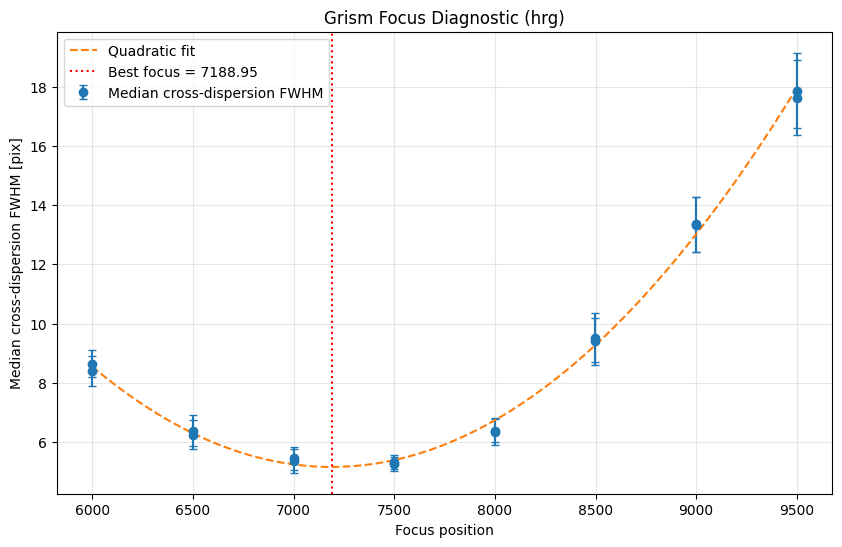

In [39]:
filter = 'hrg'

hrg_focus_results = measure_grism_focus_fwhm(
    img_files_hrg[2:],
    spectrum_class=spectrum,
    filter=filter,
    columns=[1800, 1900, 2000, 2100, 2200, 2300, 2400],
    column_half_width=5,
    profile_half_height=30,
    plot_profiles = False,
    plot_summary = True,
)


Processing 1/24: None 2026-04-21 04:39:19.95
Focus position: 6000.31264244664

Processing 2/24: None 2026-04-21 04:39:24.33
Focus position: 6000.21144275661

Processing 3/24: None 2026-04-21 04:39:32.14
Focus position: 6349.79177625481

Processing 4/24: None 2026-04-21 04:39:36.58
Focus position: 6349.79177625481

Processing 5/24: None 2026-04-21 04:39:44.33
Focus position: 6699.79198080737

Processing 6/24: None 2026-04-21 04:39:48.70
Focus position: 6699.79198080737

Processing 7/24: None 2026-04-21 04:39:56.52
Focus position: 7049.78787899015

Processing 8/24: None 2026-04-21 04:40:00.89
Focus position: 7049.78787899015

Processing 9/24: None 2026-04-21 04:40:08.70
Focus position: 7399.78808354271

Processing 10/24: None 2026-04-21 04:40:13.14
Focus position: 7399.78808354271

Processing 11/24: None 2026-04-21 04:40:20.90
Focus position: 7749.79474764996

Processing 12/24: None 2026-04-21 04:40:25.27
Focus position: 7749.79474764996

Processing 13/24: None 2026-04-21 04:40:33.14
Fo

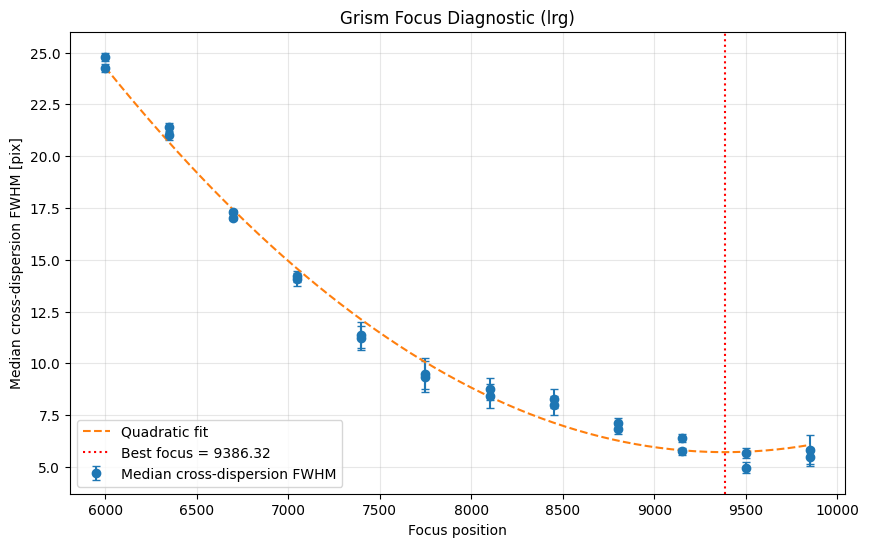

In [30]:
filter = 'lrg'

lrg_focus_results = measure_grism_focus_fwhm(
    img_files_lrg,
    spectrum_class=spectrum,
    filter=filter,
    columns=[2000, 2100, 2200, 2300, 2400, 2500, 2600],
    column_half_width=5,
    profile_half_height=30,
    plot_profiles = False,
    plot_summary = True,
)

## Focus Offsets Determination

In [31]:
def compare_grism_focus_results(
    focus_results_list,
    labels=None,
    focus_reference=None,
    fit_degree=2,
    plot=True
):
    """
    Compare multiple grism focus-result lists on one plot and determine offsets.

    Parameters
    ----------
    focus_results_list : list
        List of result lists, e.g. [hrg_focus_results, lrg_focus_results].
    labels : list or None
        Dataset labels, e.g. ["HRG", "LRG"].
    focus_reference : float or None
        Reference/photometric focus position. Offset = best_focus - focus_reference.
    fit_degree : int
        Usually 2 for quadratic focus curve.
    plot : bool
        Whether to plot.

    Returns
    -------
    summary : dict
        Best focus and offset info for each dataset.
    """

    if labels is None:
        labels = [f"Dataset {i}" for i in range(len(focus_results_list))]

    summary = {}

    fig, ax = plt.subplots(figsize=(10, 6)) if plot else (None, None)

    colors = plt.cm.tab10(np.linspace(0, 1, len(focus_results_list)))

    for results, label, color in zip(focus_results_list, labels, colors):
        focus_vals = np.array([r["focus"] for r in results], dtype=float)
        med_fwhm = np.array([r["median_fwhm"] for r in results], dtype=float)
        std_fwhm = np.array([r["std_fwhm"] for r in results], dtype=float)

        good = np.isfinite(focus_vals) & np.isfinite(med_fwhm)

        if np.sum(good) < fit_degree + 1:
            print(f"{label}: not enough good points to fit.")
            summary[label] = {
                "best_focus": np.nan,
                "focus_offset": np.nan,
                "poly_coeffs": None,
                "n_points": int(np.sum(good)),
            }
            continue

        p = np.polyfit(focus_vals[good], med_fwhm[good], fit_degree)

        best_focus = np.nan
        if fit_degree == 2 and p[0] != 0:
            best_focus = -p[1] / (2 * p[0])

        offset = np.nan
        if focus_reference is not None and np.isfinite(best_focus):
            offset = best_focus - focus_reference

        summary[label] = {
            "best_focus": best_focus,
            "focus_offset": offset,
            "poly_coeffs": p,
            "n_points": int(np.sum(good)),
            "focus_values": focus_vals[good],
            "median_fwhm": med_fwhm[good],
            "std_fwhm": std_fwhm[good],
        }

        if plot:
            ax.errorbar(
                focus_vals[good],
                med_fwhm[good],
                yerr=std_fwhm[good],
                fmt="o",
                capsize=3,
                color=color,
                label=f"{label} data"
            )

            xfit = np.linspace(np.nanmin(focus_vals[good]), np.nanmax(focus_vals[good]), 300)
            yfit = np.polyval(p, xfit)
            ax.plot(xfit, yfit, "--", color=color, label=f"{label} fit")

            if np.isfinite(best_focus):
                ax.axvline(best_focus, color=color, linestyle=":", alpha=0.8)

    if plot:
        if focus_reference is not None:
            ax.axvline(
                focus_reference,
                color="k",
                linestyle="-.",
                alpha=0.8,
                label=f"Reference focus = {focus_reference:.2f}"
            )

        ax.set_xlabel("Focus position")
        ax.set_ylabel("Median cross-dispersion FWHM [pix]")
        ax.set_title("Grism Focus Comparison")
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()

    print("\nFocus summary")
    print("-------------")
    if focus_reference is not None:
        print(f"Reference focus: {focus_reference:.3f}")

    for label, info in summary.items():
        print(f"{label}:")
        print(f"  best focus = {info['best_focus']:.3f}")
        if focus_reference is not None:
            print(f"  offset     = {info['focus_offset']:+.3f}")

    return summary

HRG focus values from headers: [7863, 7909.16488077923]
LRG focus values from headers: [7904, 7880.19593121263]
Average HRG focus: 7889.090202997965


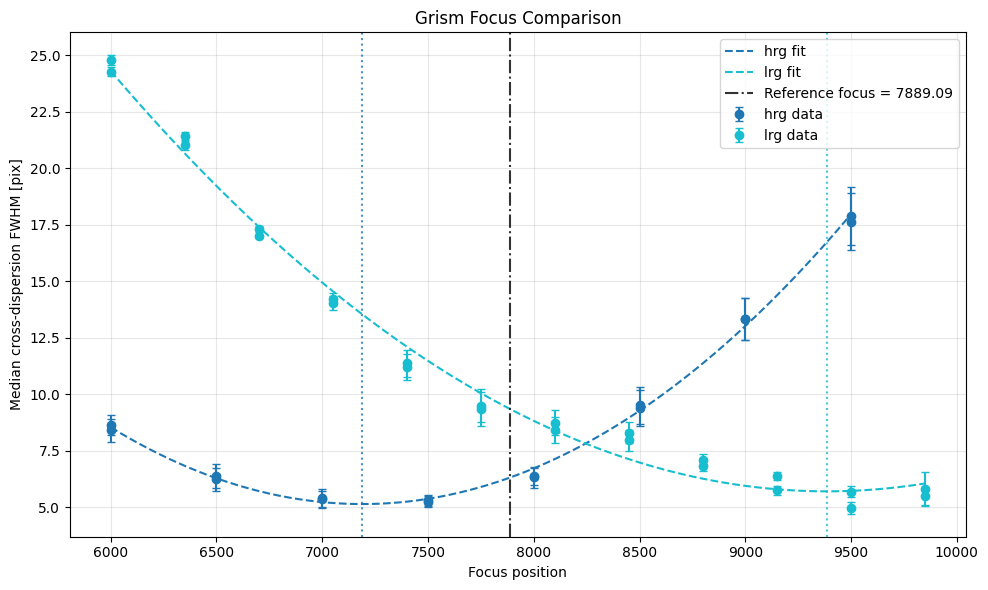


Focus summary
-------------
Reference focus: 7889.090
hrg:
  best focus = 7188.949
  offset     = -700.142
lrg:
  best focus = 9386.322
  offset     = +1497.232


In [ ]:
g_files_hrg = glob.glob(img_dir + '/Temp*hrg*.fz')
g_files_lrg = glob.glob(img_dir + '/Temp*lrg*.fz')

g_hrg_foci = []
g_lrg_foci = []

for f in g_files_hrg:
    im, hdr = getdata(f, 1, header=True)
    g_hrg_foci.append(hdr['FOCPOS'] if 'FOCPOS' in hdr else hdr['FOCUSPOS'])

for f in g_files_lrg:
    im, hdr = getdata(f, 1, header=True)
    g_lrg_foci.append(hdr['FOCPOS'] if 'FOCPOS' in hdr else hdr['FOCUSPOS'])

avg_focus = (np.mean(g_hrg_foci) + np.mean(g_lrg_foci)) / 2

print("g focus values from headers:", g_hrg_foci)
print("g focus values from headers:", g_lrg_foci)
print('Average g focus:', avg_focus)

focus_summary = compare_grism_focus_results(
    [hrg_focus_results, lrg_focus_results],
    labels=["hrg", "lrg"],
    focus_reference=avg_focus,   # replace with photometric focus position
    fit_degree=2,
    plot=True
)

# Optimization via Spectral Feature FWHM

This is a suboptimal procedure but I thought I would leave the code here in case this methodology is useful in the future

## HRG

Focus: 5500


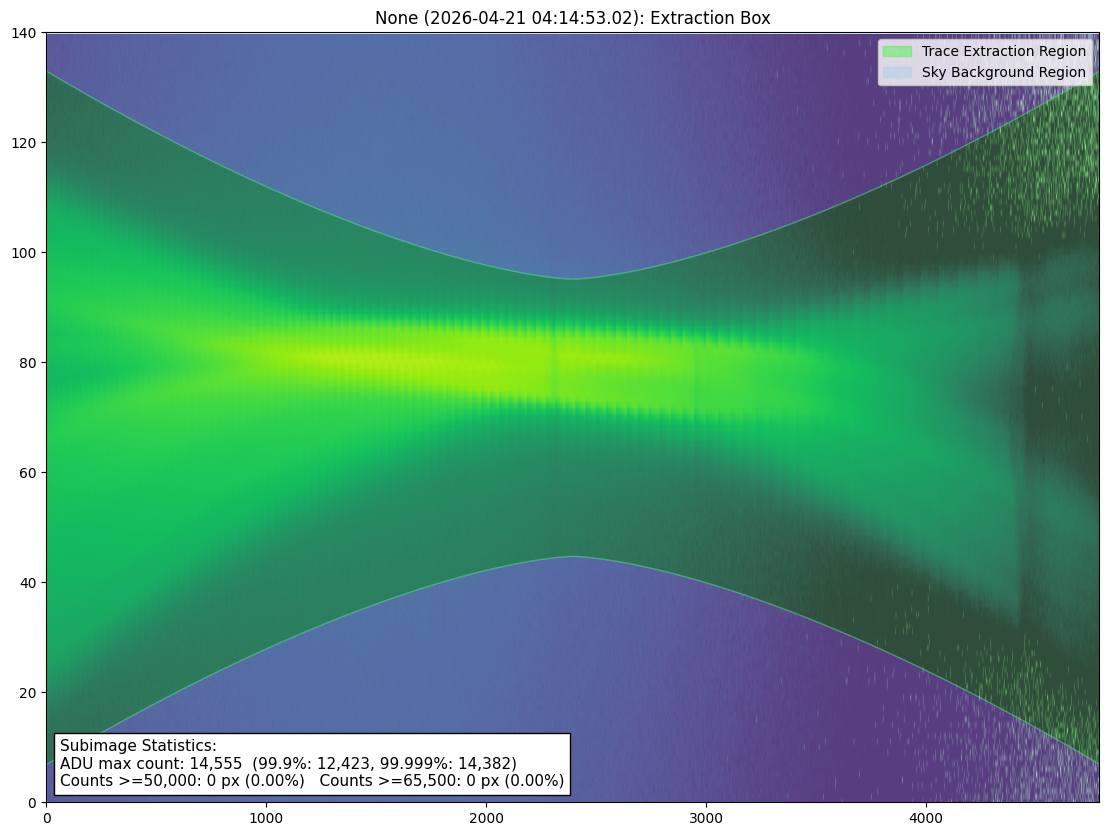

/Users/joshuamarine/Desktop/Code/grism_utils_v2.py:592: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


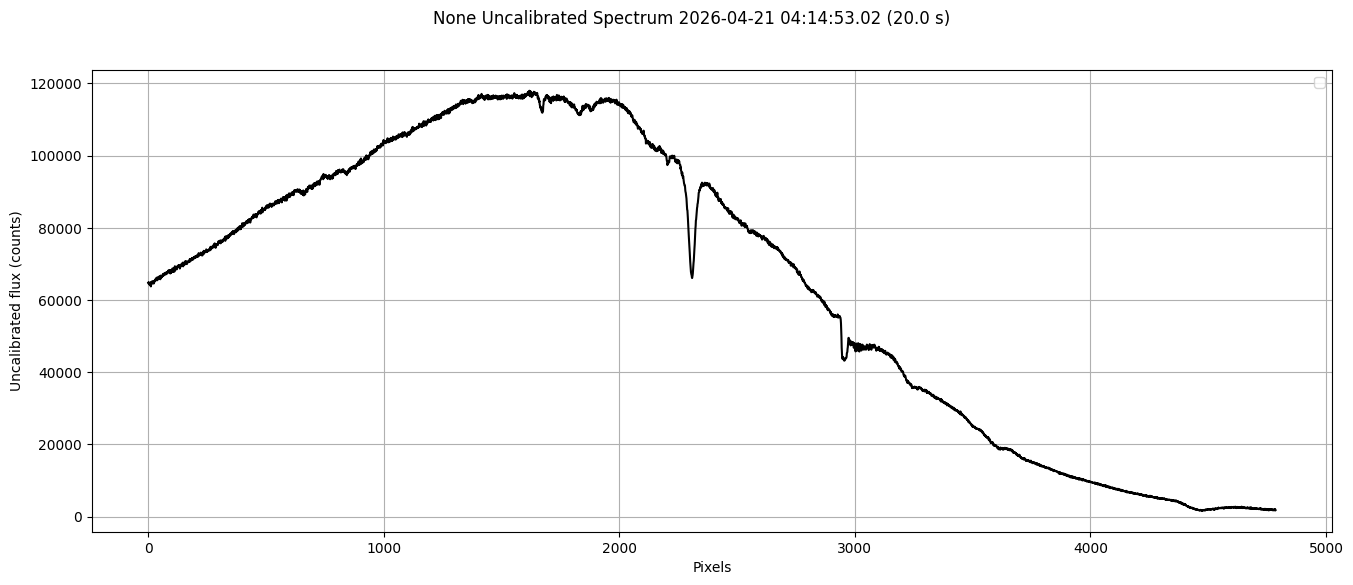

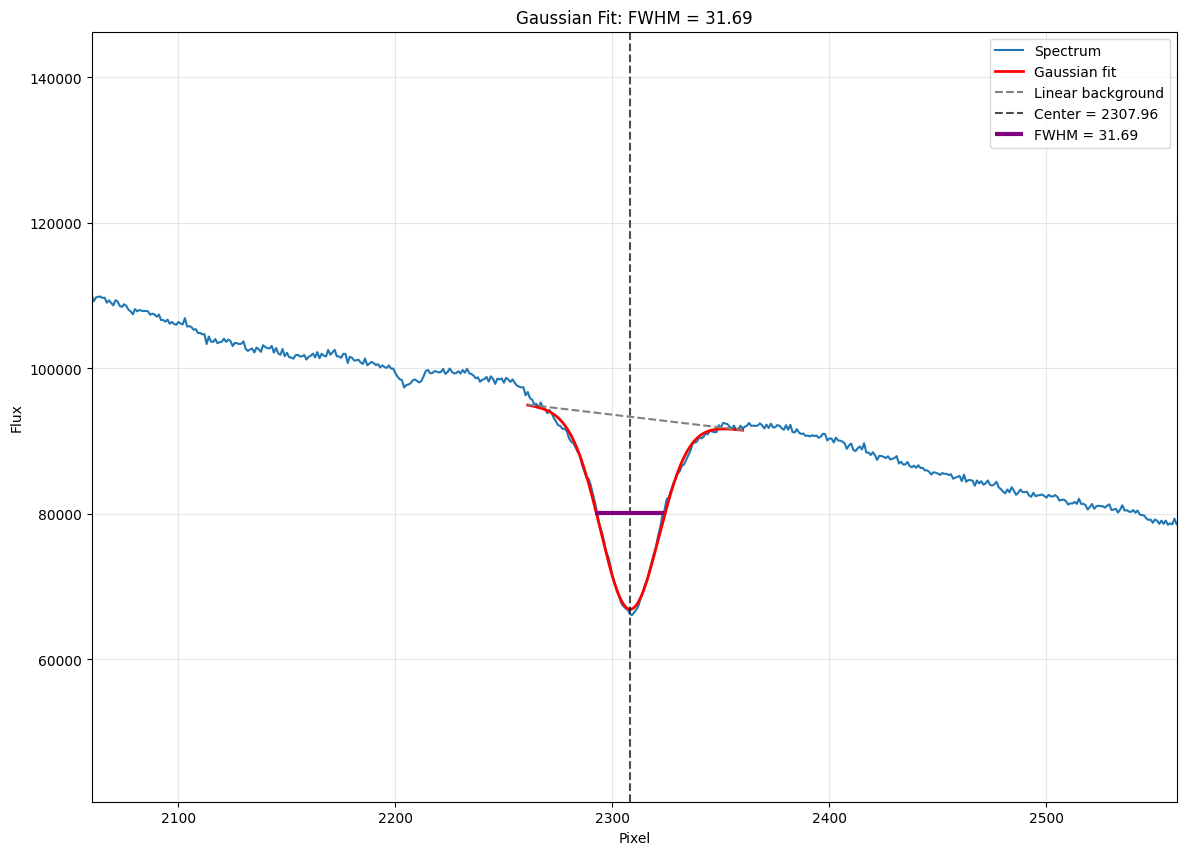

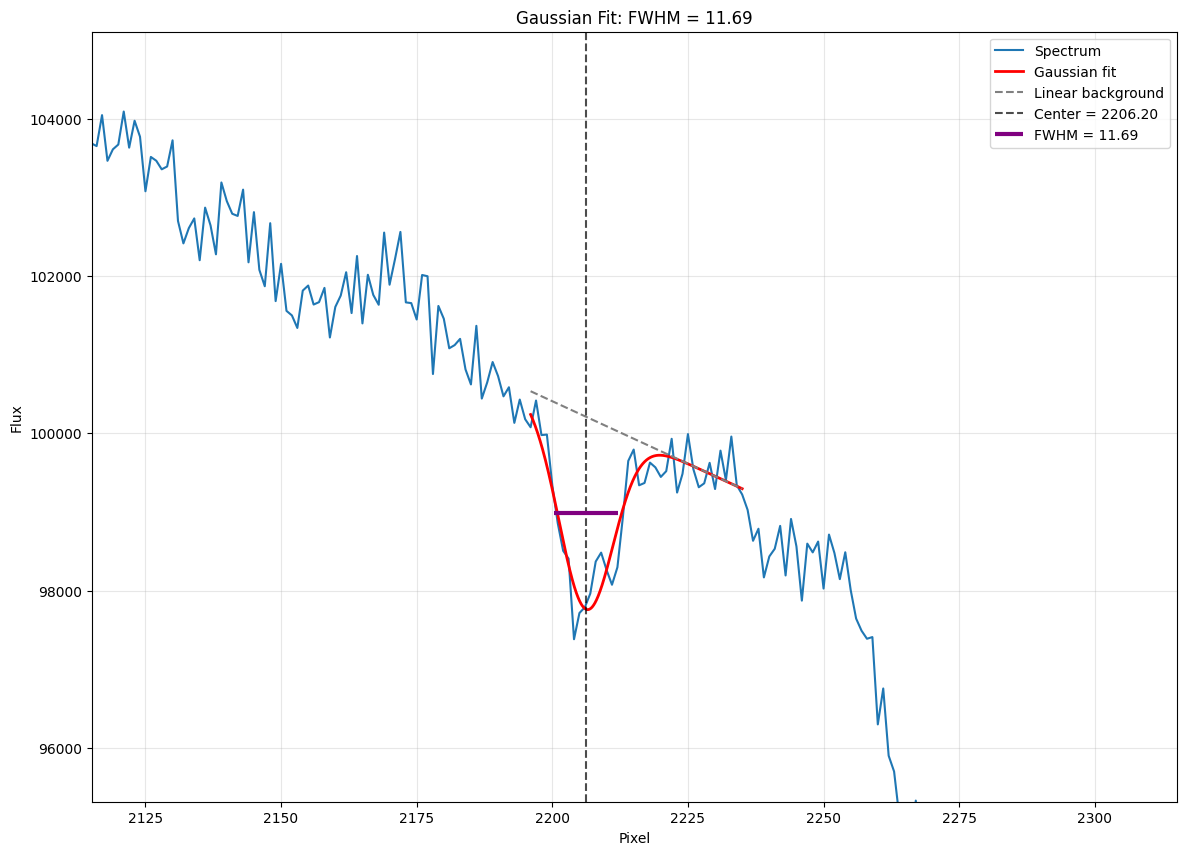

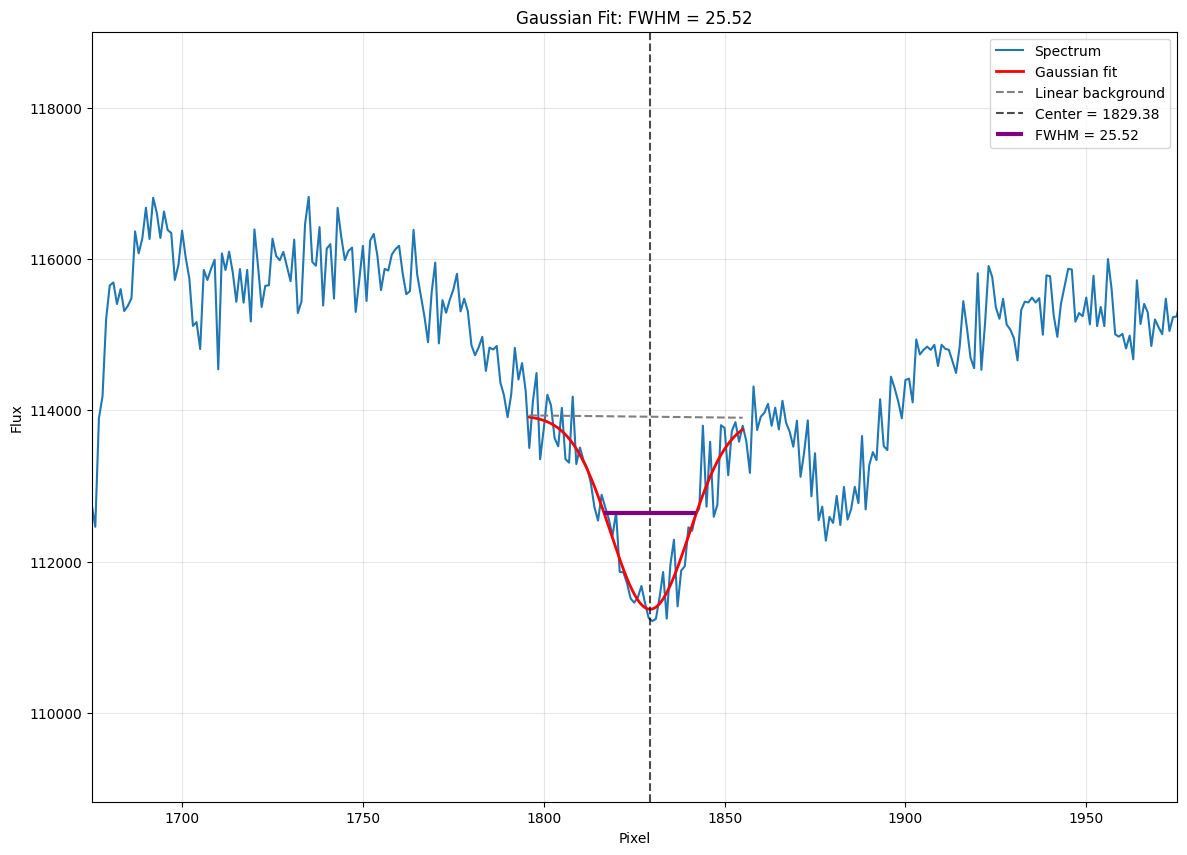

25.518364910380523


In [249]:
test_file = img_files_hrg[0]

S = spectrum(test_file, calib_spectrum = None, calib_img = False, filter = 'hrg')

print(f'Focus: {S.hdr["FOCUSPOS"]}')

trace_center, cutouts, subim = S.fit_trace(plot = False, show_points = False,curved = True)
spec = S.extract_spectrum(show_box = True, plot = True, curved_box = True)
telluric_pixel = S.fit_telluric(plot = False, debugging = False)

result = fit_gaussian_fwhm(
    spec[0],
    spec[1],
    x0=telluric_pixel - 645,
    window=50,
    absorption=True
)

result = fit_gaussian_fwhm(
    spec[0],
    spec[1],
    x0=telluric_pixel - 740,
    window=20,
    absorption=True
)

result = fit_gaussian_fwhm(
    spec[0],
    spec[1],
    x0=telluric_pixel - 1130,
    window=30,
    absorption=True
)

print(result["fwhm"])

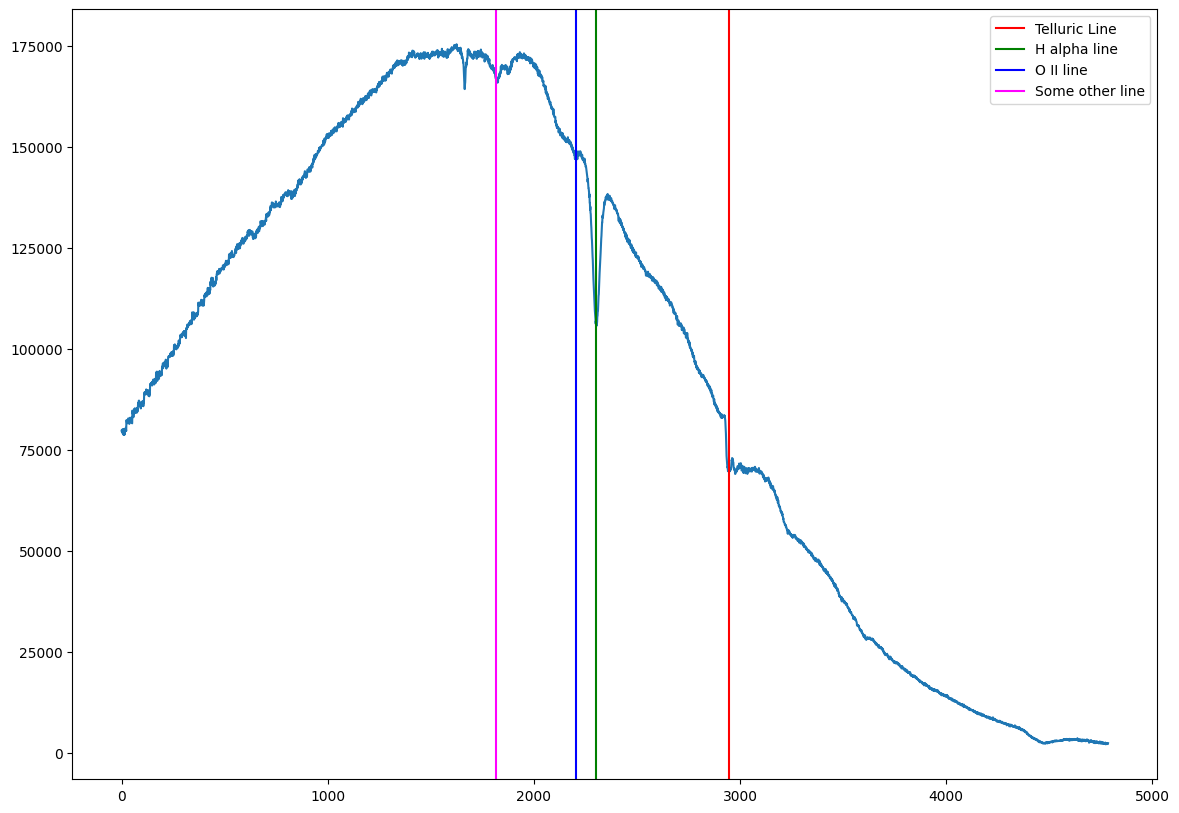

In [235]:
# Testing to see where features are

fig = plt.figure(figsize=(14,10))
plt.plot(spec[0], spec[1])
plt.axvline(telluric_pixel, color = 'r', label = 'Telluric Line')
plt.axvline(telluric_pixel - 645, color = 'g', label = 'H alpha line')
plt.axvline(telluric_pixel - 740, color = 'b', label = 'He line')
plt.axvline(telluric_pixel - 1130, color = 'magenta', label = 'Some other line')
plt.legend()
plt.show()

In [243]:
hrg_foci = []
hrg_ha_fwhms = []
hrg_he_fwhms = []
hrg_other_fwhms = []

for img in img_files_hrg:
    S = spectrum(img, calib_spectrum = None, calib_img = False, filter = 'hrg')
    trace_center, cutouts, subim = S.fit_trace(plot = False, show_points = False,curved = True)
    spec = S.extract_spectrum(show_box = False, plot = False, curved_box = True)
    telluric_pixel = S.fit_telluric(plot = False, debugging = False)
    focus = S.hdr['FOCPOS']
    ha_result = fit_gaussian_fwhm(
        spec[0],
        spec[1],
        x0=telluric_pixel - 645,
        window=50,
        absorption=True,
        plot = False
    )
    he_result = fit_gaussian_fwhm(
         spec[0],
         spec[1],  
         x0=telluric_pixel - 640,
         window=20,
         absorption=True,
         plot = False
    )
    other_result = fit_gaussian_fwhm(
        spec[0],
        spec[1],  
        x0=telluric_pixel - 1130,
        window=30,
        absorption=True,
        plot = False
    )
    print(f'Focus: {focus}, Hα FWHM: {ha_result["fwhm"]}, O II FWHM: {he_result["fwhm"]}, Other FWHM: {other_result["fwhm"]}')
    hrg_foci.append(focus)
    hrg_ha_fwhms.append(ha_result["fwhm"])
    hrg_he_fwhms.append(he_result["fwhm"])
    hrg_other_fwhms.append(other_result["fwhm"])

Focus: 5500.21176573435, Hα FWHM: 31.685745639325354, O II FWHM: 26.129364508165224, Other FWHM: 25.518364910380523
Focus: 5500.21176573435, Hα FWHM: 31.75950895612281, O II FWHM: 25.851759752019195, Other FWHM: 27.605558391591398
Focus: 6000.06933255359, Hα FWHM: 31.839896282637998, O II FWHM: 27.1921547766282, Other FWHM: 30.359450096647876
Focus: 6000.06933255359, Hα FWHM: 31.634331121871167, O II FWHM: 28.011129335679907, Other FWHM: 27.899561522506005
Focus: 6499.7955550943, Hα FWHM: 32.16118623595989, O II FWHM: 26.700039146633376, Other FWHM: 22.74864465870263
Focus: 6499.7955550943, Hα FWHM: 31.85077291057458, O II FWHM: 27.450608932652013, Other FWHM: 24.499256359091124
Focus: 6999.79307893167, Hα FWHM: 32.24594735620806, O II FWHM: 27.279699276111085, Other FWHM: 23.353608241872674
Focus: 6999.79307893167, Hα FWHM: 32.62411506664693, O II FWHM: 28.66749621876375, Other FWHM: 22.29396610059601
Focus: 7500.2147801932, Hα FWHM: 33.46211105517818, O II FWHM: 28.48043741851315, Ot

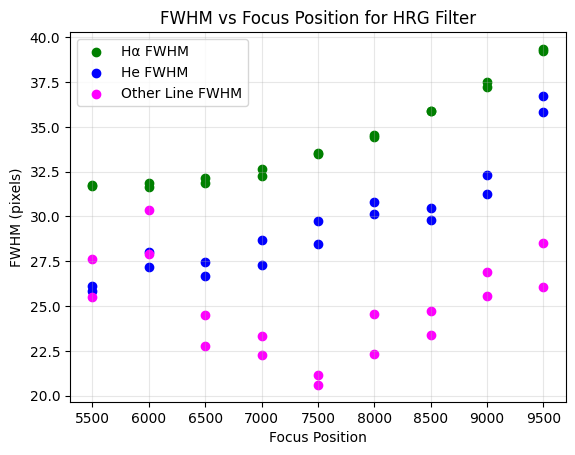

In [244]:
plt.scatter(hrg_foci, hrg_ha_fwhms, label='Hα FWHM', color='g')
plt.scatter(hrg_foci, hrg_he_fwhms, label='He FWHM', color='b')
plt.scatter(hrg_foci, hrg_other_fwhms, label='Other Line FWHM', color='magenta')
plt.xlabel('Focus Position')
plt.ylabel('FWHM (pixels)')
plt.title('FWHM vs Focus Position for HRG Filter')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## LRG

Focus: 9499


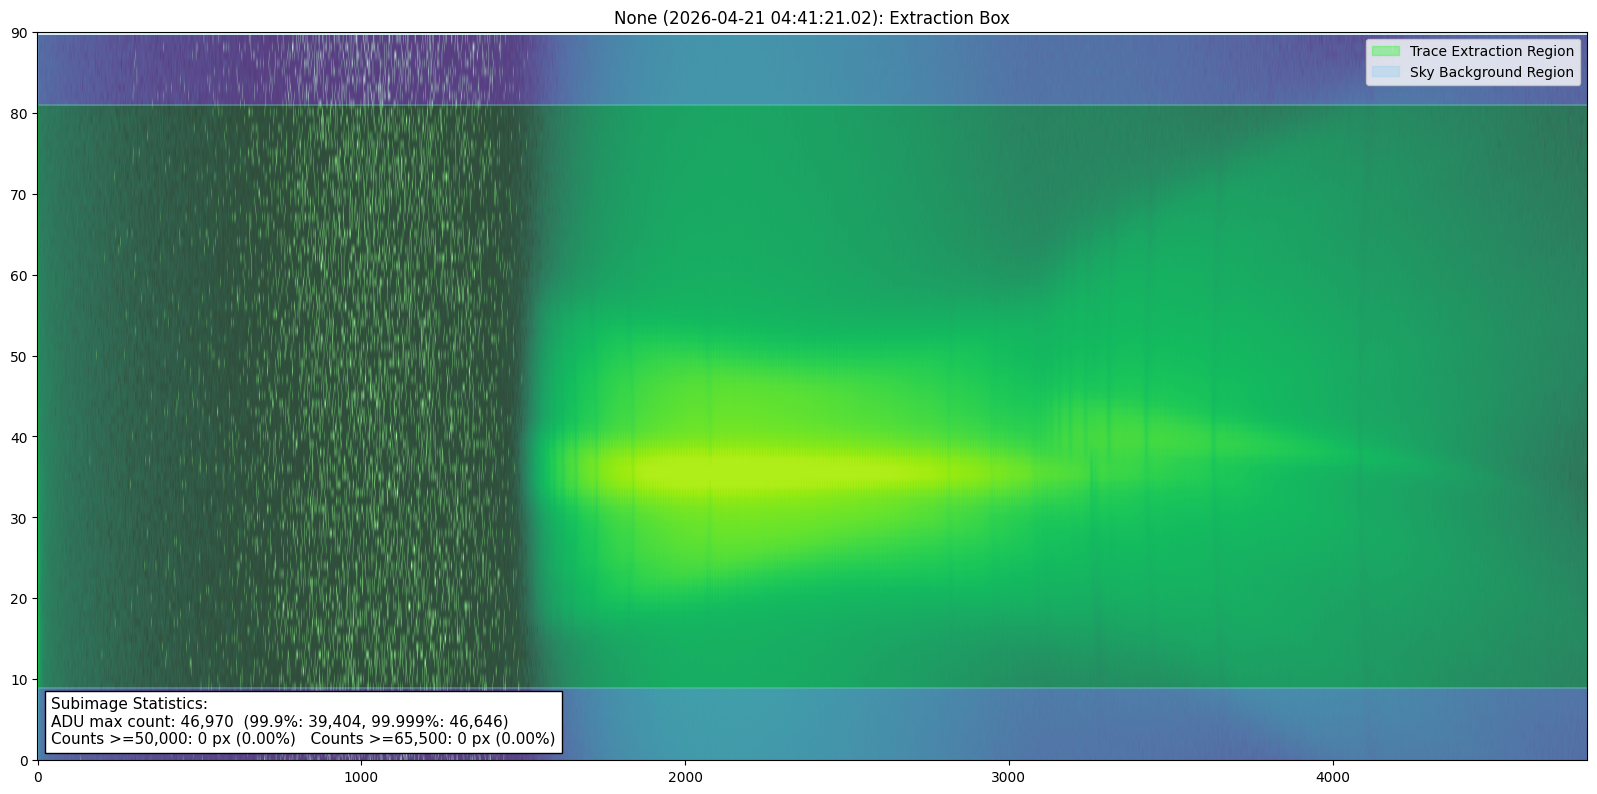

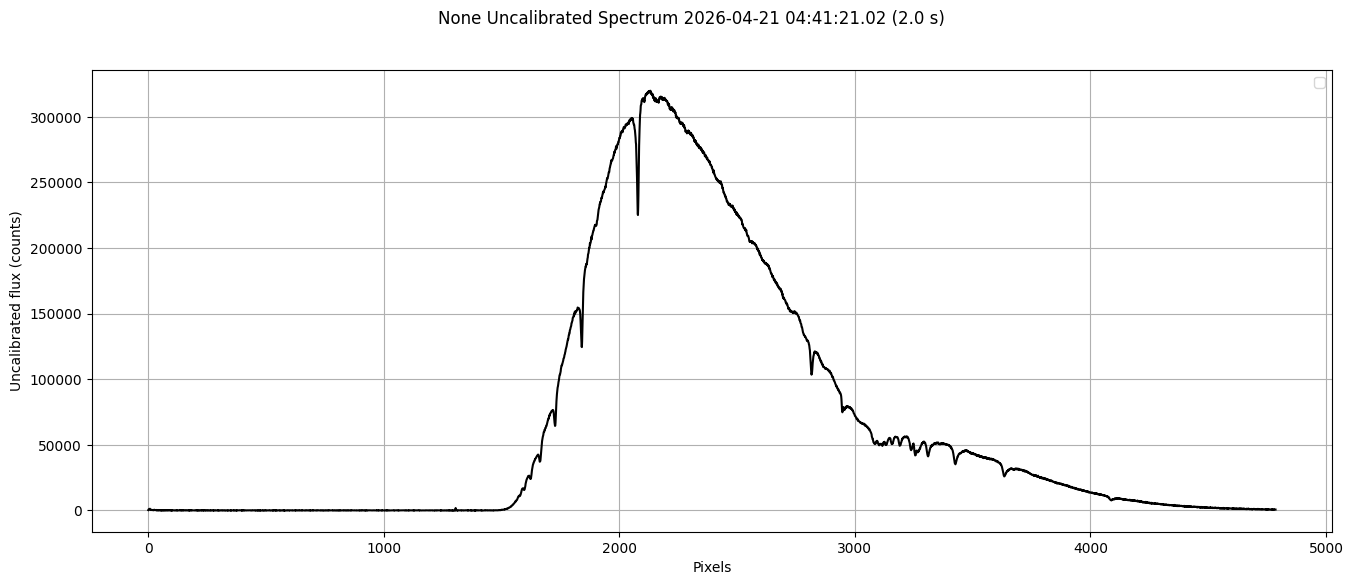

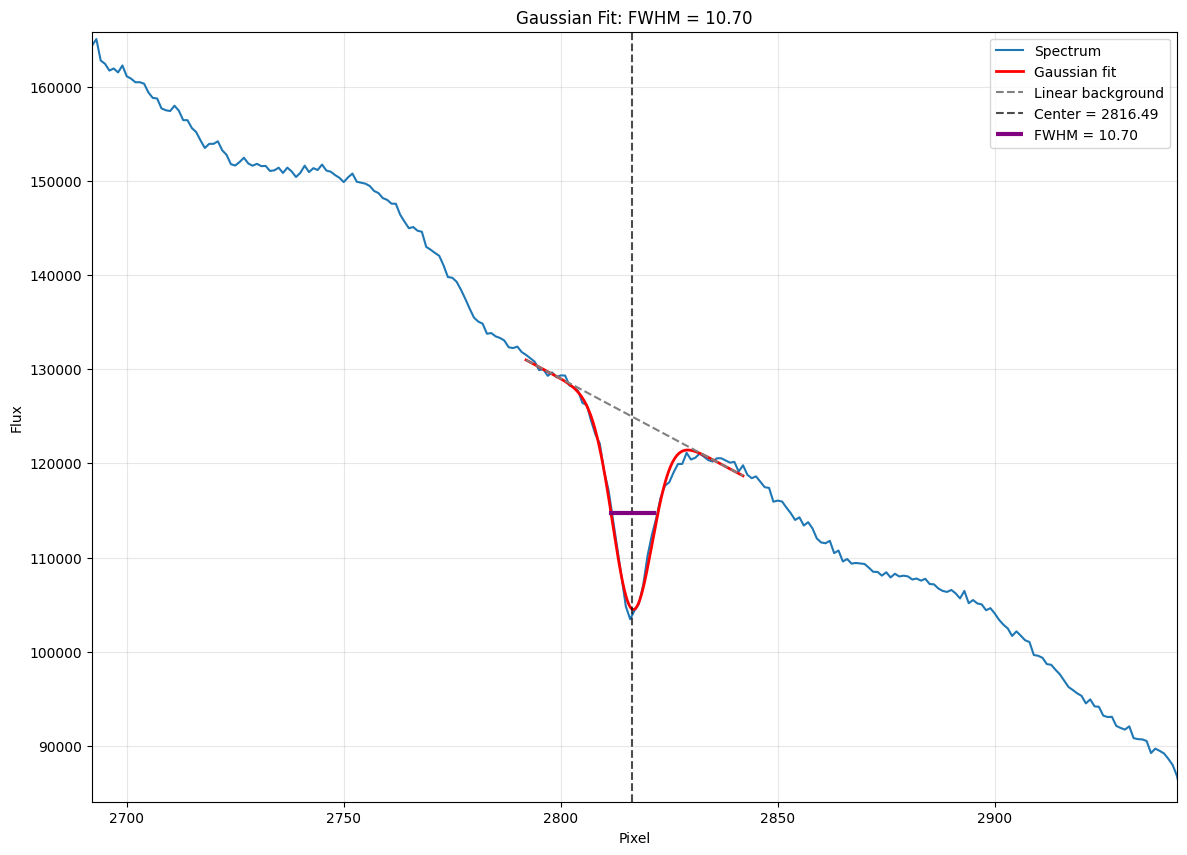

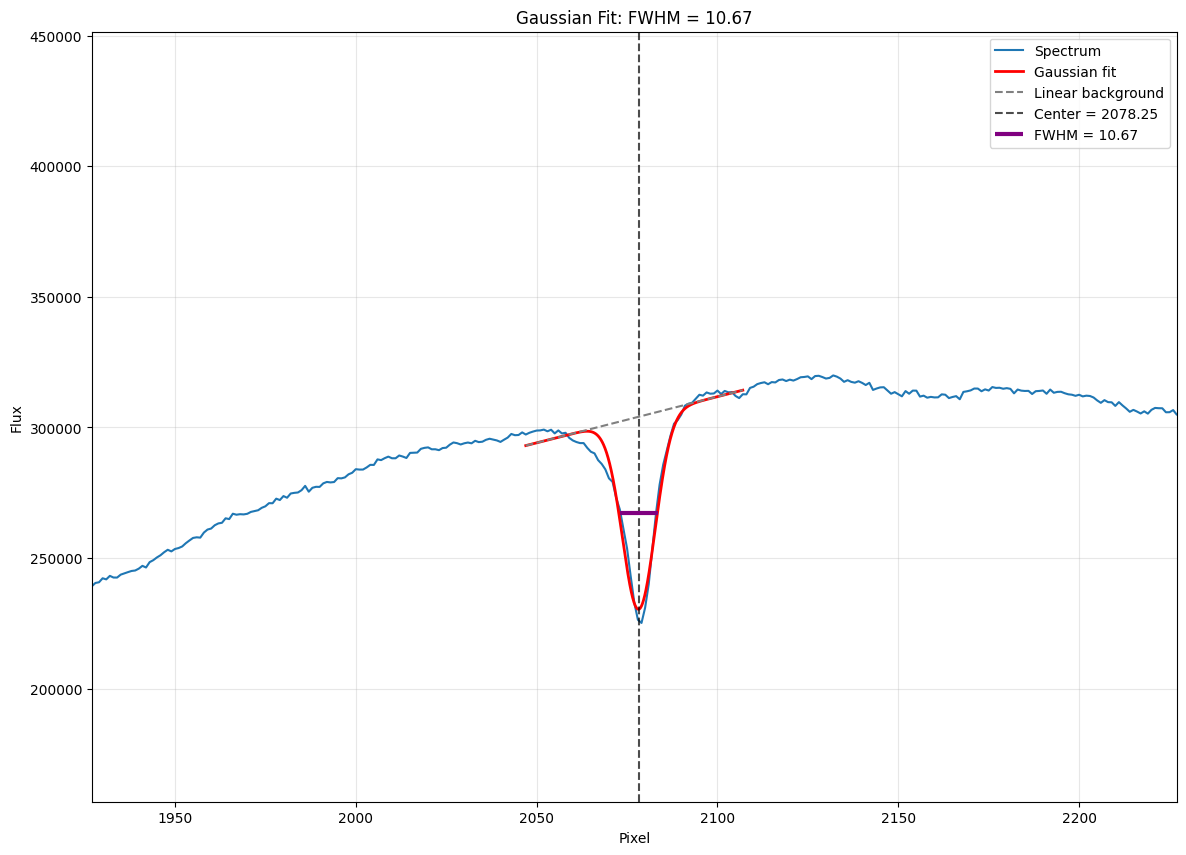

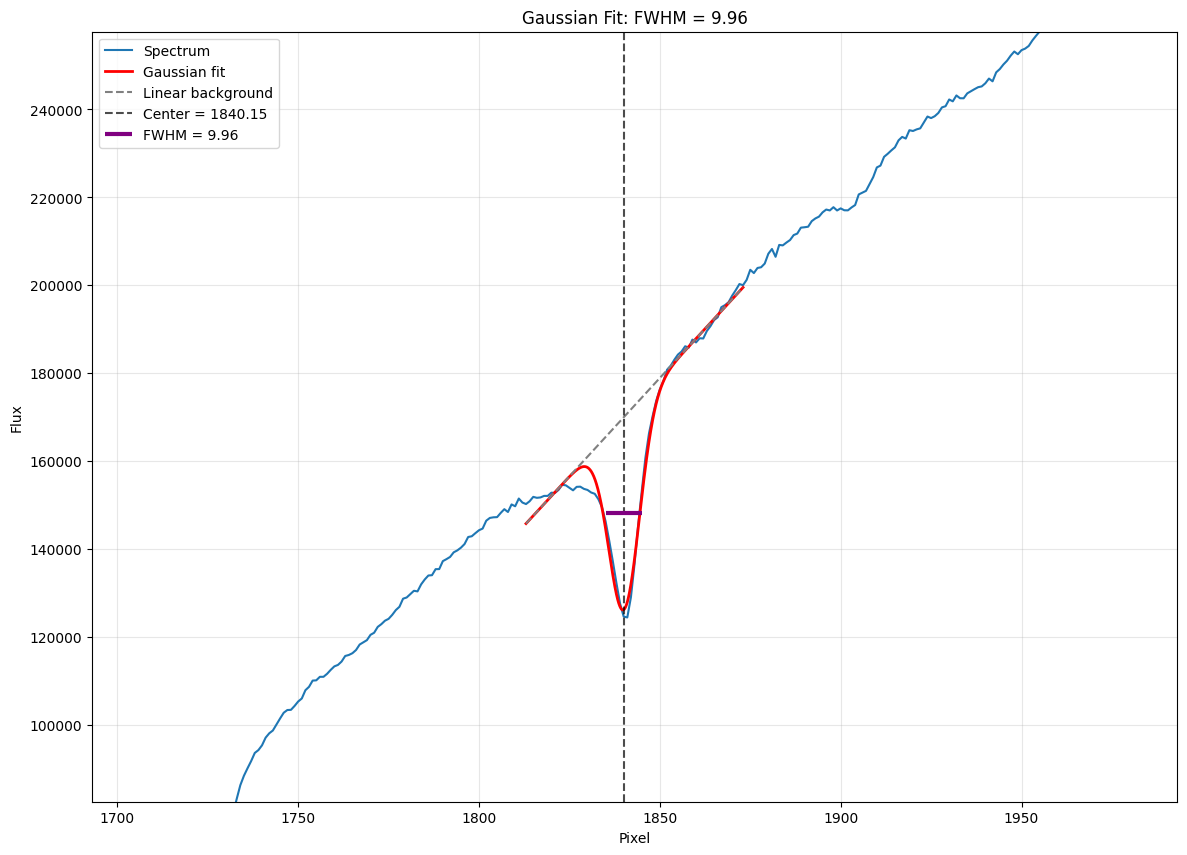

Ha FWHM: 10.699680904445565, Hβ FWHM: 10.668923368423476, Hγ FWHM: 9.959258684292786


In [262]:
test_file = img_files_lrg[20]

S = spectrum(test_file, calib_spectrum = None, calib_img = False, filter = 'lrg')

print(f'Focus: {S.hdr["FOCUSPOS"]}')

trace_center, cutouts, subim = S.fit_trace(plot = False, show_points = True,curved = True)
spec = S.extract_spectrum(show_box = True, plot = True, curved_box = True)
telluric_pixel = S.fit_telluric(x_guess = 2953, plot = False, debugging = False, manual_override = True)

Ha_result = fit_gaussian_fwhm(
    spec[0],
    spec[1],
    x0=telluric_pixel - 136,
    window=25,
    absorption=True
)

Hb_result = fit_gaussian_fwhm(
    spec[0],
    spec[1],
    x0=telluric_pixel - 876,
    window=30,
    absorption=True
)

Hg_result = fit_gaussian_fwhm(
    spec[0],
    spec[1],
    x0=telluric_pixel - 1110,
    window=30,
    absorption=True
)

print(f'Ha FWHM: {Ha_result["fwhm"]}, Hβ FWHM: {Hb_result["fwhm"]}, Hγ FWHM: {Hg_result["fwhm"]}')

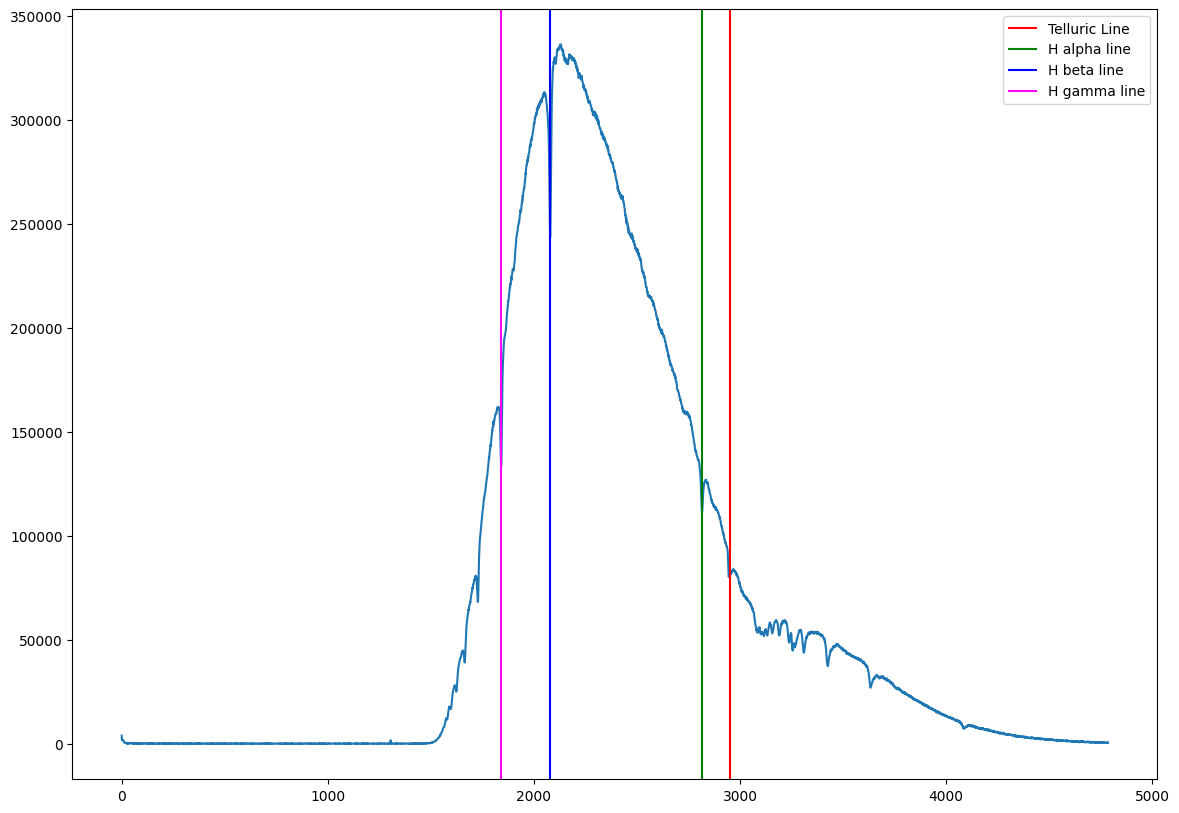

In [ ]:
# # Testing to see where features are

# fig = plt.figure(figsize=(14,10))
# plt.plot(spec[0], spec[1])
# plt.axvline(telluric_pixel, color = 'r', label = 'Telluric Line')
# plt.axvline(telluric_pixel - 138, color = 'g', label = 'H alpha line')
# plt.axvline(telluric_pixel - 876, color = 'b', label = 'H beta line')
# plt.axvline(telluric_pixel - 1110, color = 'magenta', label = 'H gamma line')
# plt.legend()
# plt.show()

In [218]:
lrg_foci = []
lrg_Ha_fwhms = []
lrg_Hb_fwhms = []
lrg_Hg_fwhms = []

for img in img_files_lrg:
    S = spectrum(img, calib_spectrum = None, calib_img = False, filter = 'lrg')
    trace_center, cutouts, subim = S.fit_trace(plot = False, show_points = False,curved = True)
    spec = S.extract_spectrum(show_box = False, plot = False, curved_box = True)
    telluric_pixel = S.fit_telluric(x_guess = 2953, plot = True, debugging = False, manual_override = True)
    focus = S.hdr['FOCPOS']
    Ha_result = fit_gaussian_fwhm(
        spec[0],
        spec[1],
        x0=telluric_pixel - 136,
        window=25,
        absorption=True,
        plot = False
    )
    Hb_result = fit_gaussian_fwhm(
        spec[0],
        spec[1],
        x0=telluric_pixel - 876,
        window=25,
        absorption=True,
        plot = False
    )
    Hg_result = fit_gaussian_fwhm(
        spec[0],
        spec[1],
        x0=telluric_pixel - 1110,
        window=30,
         absorption=True,
         plot = False
    )
    print(f'Focus: {focus}, Hα FWHM: {Ha_result["fwhm"]}, Hβ FWHM: {Hb_result["fwhm"]}, Hγ FWHM: {Hg_result["fwhm"]}')
    lrg_foci.append(focus)
    lrg_Ha_fwhms.append(Ha_result["fwhm"])
    lrg_Hb_fwhms.append(Hb_result["fwhm"])
    lrg_Hg_fwhms.append(Hg_result["fwhm"])

Focus: 6000.31264244664, Hα FWHM: 22.423251245560245, Hβ FWHM: 24.808605274313905, Hγ FWHM: 22.99010284556037
Focus: 6000.21144275661, Hα FWHM: 23.570207005734417, Hβ FWHM: 26.293758462097113, Hγ FWHM: 24.11310935800317
Focus: 6349.79177625481, Hα FWHM: 19.949738282664015, Hβ FWHM: 22.17879020220612, Hγ FWHM: 22.590868177820496
Focus: 6349.79177625481, Hα FWHM: 19.550079525809128, Hβ FWHM: 21.286716796182013, Hγ FWHM: 22.11785434145351
Focus: 6699.79198080737, Hα FWHM: 16.799456065979225, Hβ FWHM: 18.6385868656788, Hγ FWHM: 20.459748256809906
Focus: 6699.79198080737, Hα FWHM: 17.154301728839986, Hβ FWHM: 18.84436410211425, Hγ FWHM: 20.32761081281046
Focus: 7049.78787899015, Hα FWHM: 15.280747317365583, Hβ FWHM: 16.720884785949576, Hγ FWHM: 18.90630230923005
Focus: 7049.78787899015, Hα FWHM: 15.010420137358185, Hβ FWHM: 17.037980549154998, Hγ FWHM: 19.25381018267267
Focus: 7399.78808354271, Hα FWHM: 13.648656829750498, Hβ FWHM: 15.201406946332224, Hγ FWHM: 17.575222081432198
Focus: 7399

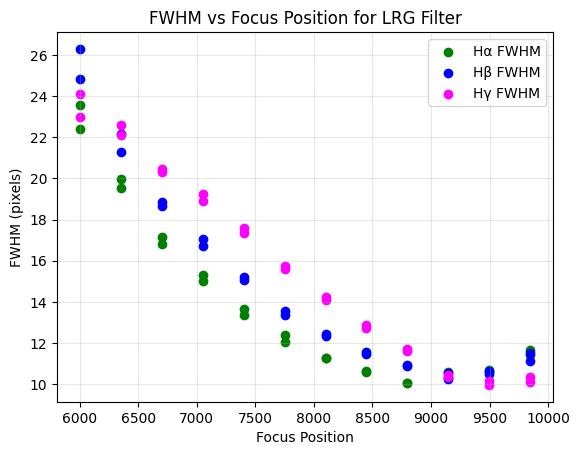

In [220]:
plt.scatter(lrg_foci, lrg_Ha_fwhms, label='Hα FWHM', color='g')
plt.scatter(lrg_foci, lrg_Hb_fwhms, label='Hβ FWHM', color='b')
plt.scatter(lrg_foci, lrg_Hg_fwhms, label='Hγ FWHM', color='magenta')
plt.xlabel('Focus Position')
plt.ylabel('FWHM (pixels)')
plt.title('FWHM vs Focus Position for LRG Filter')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# Old Code

In [6]:
def plot_img(img_data, aspect_ratio=1):
    plt.imshow(img_data, cmap='gray', origin='lower')
    plt.gca().set_aspect(aspect_ratio)
    plt.colorbar()
    plt.show()

def extract_strip(img_data, height, center_row):
    strip_data = img_data[center_row - height//2:center_row + height//2, :]
    return strip_data

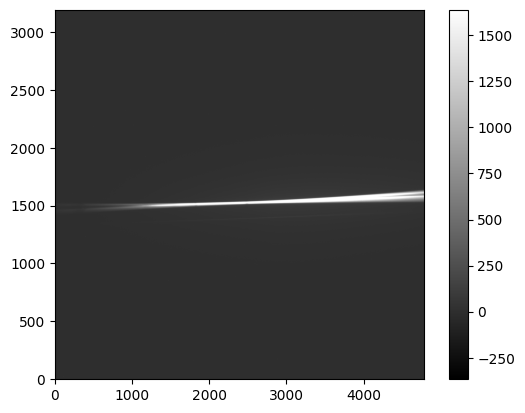

In [76]:
test_data = fits.getdata(test_file)
mean = np.mean(test_data)
std = np.std(test_data)
normalize = Normalize(vmin = mean - std, vmax = mean + 4*std)
plt.imshow(test_data, norm = normalize, cmap='gray', origin='lower')
plt.gca().set_aspect(1.5)
plt.colorbar()
plt.show()

In [8]:
def fit_line(data, xlow = None, xhigh = None, ylow = None, yhigh = None, min_intensity = None, recursion = 0):

    if xlow is None:
        xlow = 0
    if xhigh is None:
        xhigh = data.shape[1]
    if ylow is None:
        ylow = 0
    if yhigh is None:
        yhigh = data.shape[0]
    if min_intensity is None:
        min_intensity = 3*np.mean(data)

    if recursion > 30:
        print('')
        print('Unable to fit spectral trace')
        print('')
        return
    
    if data.shape[0] < data.shape[1]:
        plot_data = data
        data = np.transpose(data)
    else:
        plot_data = np.transpose(data)
    
    x_fit = []
    y_fit = []
    for i in range(data.shape[0]):
        max_x_coord = i
        max_y_coord = np.where(data[i] == np.max(data[i]))[0][0]
        if max_x_coord < xlow or max_x_coord > xhigh:
            continue
        if max_y_coord < ylow or max_y_coord > yhigh:
            continue
        else:
            x_fit.append(max_x_coord)
            y_fit.append(max_y_coord)
            
    a = 0
    while a < len(y_fit):
        if data[x_fit[a]][y_fit[a]] < min_intensity:
            del x_fit[a]
            del y_fit[a]
        else:
            a+=1
            continue
    
    if len(y_fit) < (xhigh-xlow)/4:
        # print("Re-fit, not enough data points")
        # print('Failed to make fit, trying a new min_intensity parameter...')
        new_min_intensity = min_intensity - 0.25*np.mean(data)
        return fit_line(data,xlow = xlow,xhigh = xhigh,ylow = ylow,yhigh = yhigh,min_intensity = new_min_intensity, recursion = recursion)

    x_fit = np.array(x_fit)
    y_fit = np.array(y_fit)
    
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_fit, y_fit)
    y_pred = intercept + slope * x_fit
    residuals = y_fit - y_pred
    
    threshold = .15 * np.std(residuals)
    outliers = np.abs(residuals) > threshold
    x_fit = x_fit[~outliers]
    y_fit = y_fit[~outliers]

    joshfit = np.polyfit(x_fit,y_fit,1)
    m, b = joshfit[0], joshfit[1]
    x=np.linspace(0,data.shape[1]-1,data.shape[1])
    fitline = m*x + b

    poly = np.poly1d(joshfit)
    yfit = poly(x_fit)
    residuals = y_fit - yfit
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((yfit - np.mean(yfit))**2)
    r_squared = 1 - (ss_res / ss_tot)

    if np.abs(r_squared) > 1.1 or np.abs(r_squared) < 0.9:
        # print("Re-Fit, poor r squared value")
        new_min_intensity = min_intensity + 0.02*np.mean(data)
        return fit_line(data,xlow = xlow,xhigh = xhigh,ylow = ylow,yhigh = yhigh,min_intensity = new_min_intensity, recursion = recursion + 1)

    
    print('Fit Line Created: y = {:.4f}x + {:.4f}'.format(m, b))
    print(f'R-squared Value: {r_squared}')

    plt.figure(figsize = (10,10))
    mean = np.mean(data)
    std = np.std(data)
    x = np.linspace(0,plot_data.shape[1],plot_data.shape[1]+1)
    fit = joshfit[0]*x + joshfit[1]
    
    plt.imshow(plot_data,cmap = 'gray',origin = 'lower',vmin = mean - std,vmax = mean + 3*std)
    plt.colorbar()
    # plot_img(data,3)    
    plt.plot(x,fit,label = 'Fit Line (Brightest Trace)',color = 'red')
    plt.scatter(x_fit,y_fit,label = 'Fit Line Points', color = 'cyan')
    plt.gca().set_aspect(1.5)
    plt.legend()
    
    return joshfit

Fit Line Created: y = 0.0256x + 1461.5537
R-squared Value: 0.9803375231344411

The rotation angle for this image is: 1.467437816332807


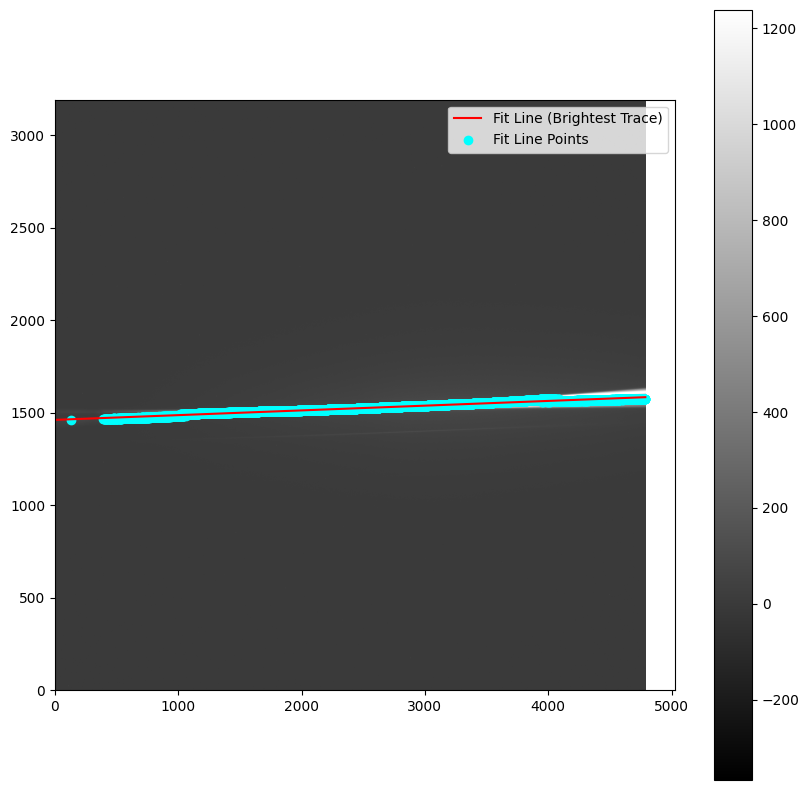

In [77]:
fitline = fit_line(test_data)

angle = np.arctan(fitline[0])
print('')
print(f'The rotation angle for this image is: {np.degrees(angle)}')

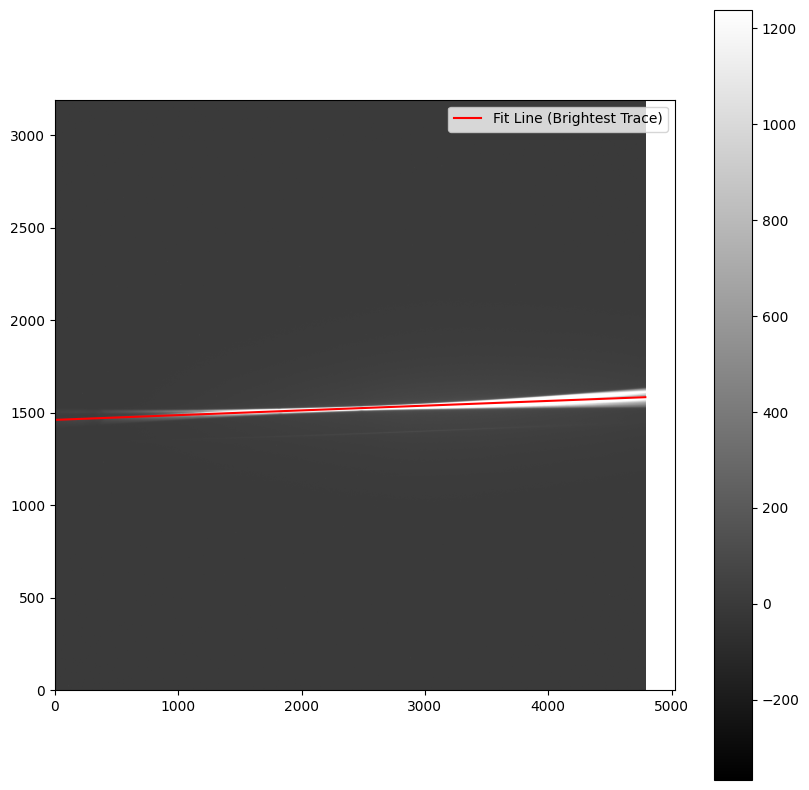

In [78]:
plt.figure(figsize = (10,10))
mean = np.mean(test_data)
std = np.std(test_data)
x = np.linspace(0,test_data.shape[1],test_data.shape[1]+1)
fit = fitline[0]*x + fitline[1]

plt.imshow(test_data,cmap = 'gray',origin = 'lower',vmin = mean - std,vmax = mean + 3*std)
# plot_img(strip_data,3)
plt.plot(x,fit,label = 'Fit Line (Brightest Trace)',color = 'red')
plt.gca().set_aspect(1.5)
plt.colorbar()
plt.legend()

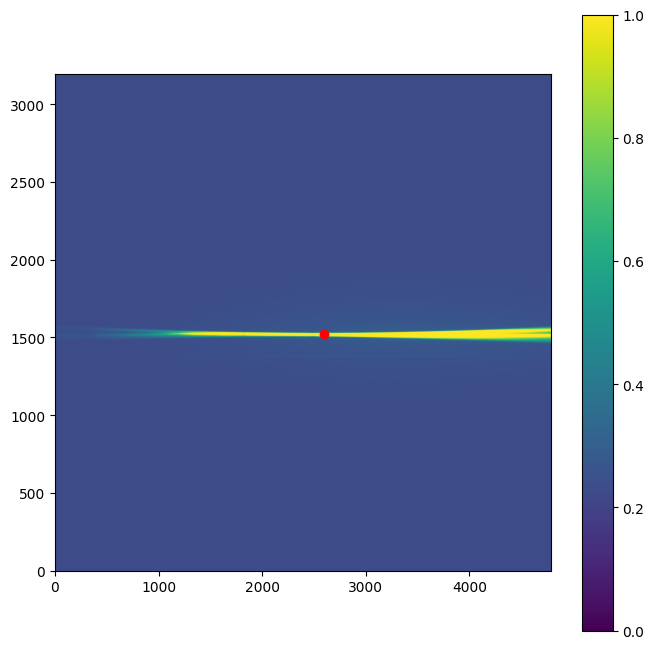

In [79]:
rotated_img = rotate(test_data, np.degrees(angle), reshape=False)
# Get the strip from the rotated image
# rotated_strip = extract_strip(rotated_img, height, ycenter)
plt.figure(figsize = (8,8))
plt.imshow(rotated_img, cmap='viridis', origin='lower', vmin = mean - std, vmax = mean + 3*std)
plt.scatter(2600,1520,color = 'red')
# Aspect ratio of 10
plt.gca().set_aspect(1.5)
plt.colorbar()
plt.show()

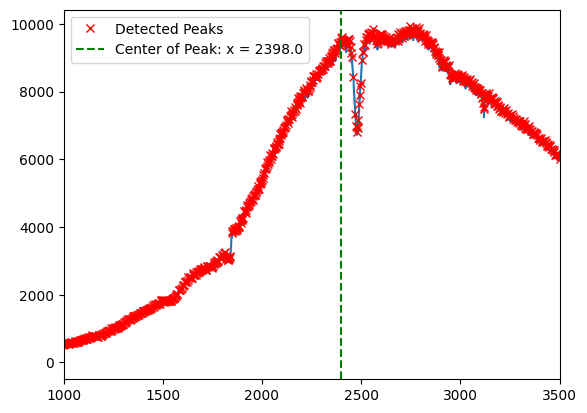

In [80]:
x = []
y = []
y_row = 1520
for i in range(rotated_img.shape[1]):
    x.append(i)
    y.append(rotated_img[y_row][i])

peaks,properties = find_peaks(y,height = 10*np.median(rotated_img))
xpeak_coord = np.median(peaks)

x = np.array(x)
y = np.array(y)

plt.plot(x,y)
plt.xlim(1000,3500)
plt.plot(x[peaks],y[peaks],'rx', label = 'Detected Peaks')
plt.axvline(x = xpeak_coord,label = f'Center of Peak: x = {xpeak_coord}', color = 'green', linestyle = '--')
plt.legend()

Width (FWHM) = 5.5577034912376355


(1450.0, 1600.0)

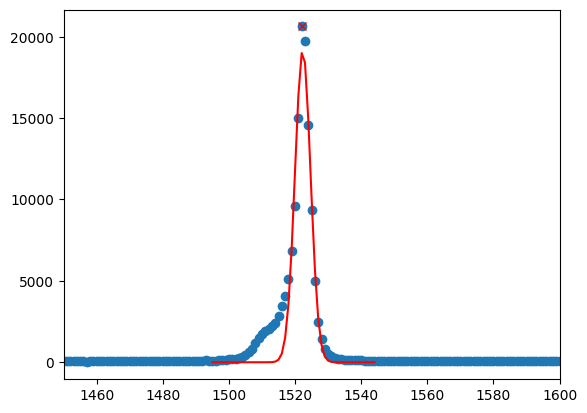

In [81]:
xlow = 1450
xhigh = 1600

col_data = np.transpose(rotated_img)
x = []
y = []
x_col = 2600
for i in range(col_data.shape[1]):
    x.append(i)
    y.append(col_data[x_col][i])

max_value = np.max(y)
x_coord = np.where(y == max_value)[0][0]

def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

x1 = x[1495:1545]
y1 = y[1495:1545]

A_initial = np.max(y1)
mu_initial = x1[np.argmax(y1)]
half_max = A_initial / 2
closest_index = np.argmin(np.abs(y1 - half_max))
sigma_initial = np.abs(x1[closest_index] - mu_initial) / np.sqrt(2 * np.log(2))

initial_guess = [A_initial, mu_initial, sigma_initial]
popt, pcov = curve_fit(gaussian, x1, y1, p0=initial_guess)

A, mu, sigma = popt
# print(f"Fitted parameters:\nA = {A}\nmu = {mu}\nsigma = {sigma}")

FWHM = np.abs(2 * np.sqrt(2 * np.log(2)) * sigma)
print(f"Width (FWHM) = {FWHM}")

plt.scatter(x,y)
plt.plot(x_coord,max_value,'rx')
plt.plot(x1, gaussian(x1, *popt), color='red', label='Fitted Gaussian')
plt.xlim(1450,1600)

In [82]:
def gaussian(x, A, mu, sigma):
            return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def find_trace_width(data,xlow,xhigh):
    rotated_img = rotate(data, np.degrees(angle), reshape=False)
    col_data = np.transpose(rotated_img)
    col_extract = col_data[xlow:xhigh]
    
    widths = []
    for x_col in range(int(col_extract.shape[0]/100)):
        x = np.linspace(0,col_extract.shape[1],col_extract.shape[1])
        y = col_extract[x_col*100]
        
        # x1 = x[1560:1600]
        # y1 = y[1560:1600]

        x1 = x[1495:1545]
        y1 = y[1495:1545]
        
        A_initial = np.max(y1)
        mu_initial = x1[np.argmax(y1)]
        half_max = A_initial / 2
        closest_index = np.argmin(np.abs(y1 - half_max))
        sigma_initial = np.abs(x1[closest_index] - mu_initial) / np.sqrt(2 * np.log(2))
        
        initial_guess = [A_initial, mu_initial, sigma_initial]
        popt, pcov = curve_fit(gaussian, x1, y1, p0=initial_guess)
        
        A, mu, sigma = popt
        
        FWHM = np.abs(2 * np.sqrt(2 * np.log(2)) * sigma)
        widths.append(FWHM)

    width_avg = np.mean(widths)
    return width_avg

In [83]:
def optimal_focus(img_list):
    widths = []
    foci = []
    print(f'Analyzing all images in list, this might take a bit...')
    for file in img_list:
        im, hdr = getdata(file, 1, header=True)
        number = hdr['FOCPOS']
        foci.append(int(number))
        file_data = fits.getdata(file)
        width = find_trace_width(file_data,xlow,xhigh)
        widths.append(width)
    
    return foci, widths

In [84]:
foci_0, widths_0 = optimal_focus(img_files_0)

Analyzing all images in list, this might take a bit...


In [44]:
foci_1, widths_1 = optimal_focus(img_files_1)

Analyzing all images in list, this might take a bit...


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

In [ ]:
# foci_2, widths_2 = optimal_focus(img_files_2)

Analyzing all images in list, this might take a bit...


In [85]:
print(widths_0)

[np.float64(15.00901242385123), np.float64(15.016172710777573), np.float64(15.470512002393777), np.float64(15.217934084703446), np.float64(15.786485048882671), np.float64(15.949721728697215), np.float64(16.826309381106054), np.float64(17.075342340804134), np.float64(19.091288885096375), np.float64(18.862833440429043), np.float64(21.775530907899174), np.float64(22.115066008371155), np.float64(25.21354816147203), np.float64(25.6971228360297), np.float64(29.908293509395612), np.float64(29.893872308545692), np.float64(34.89617565425927), np.float64(34.39245575428843)]


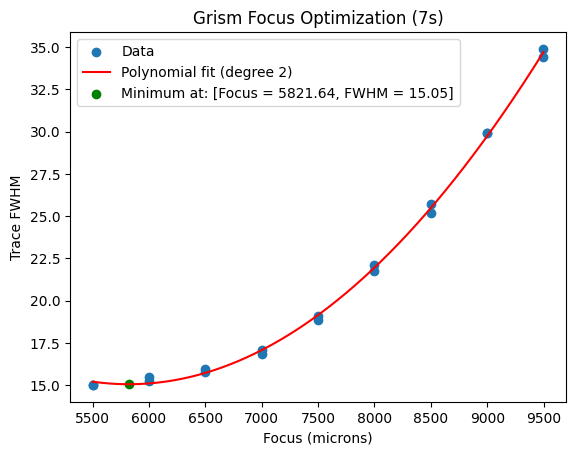

Best Spectral Resolution: FWHM = 15.050269718378729 at Focus = 5821.642688019193


In [87]:
degree = 2
coefficients = np.polyfit(foci_0, widths_0, degree)
polynomial = np.poly1d(coefficients)

def poly_function(x):
    return polynomial(x)

result = minimize(poly_function, x0=np.mean(x))

min_x = result.x[0]
min_y = polynomial(min_x)

x_fit = np.linspace(min(foci_0), max(foci_0), 1000)
y_fit = polynomial(x_fit)

plt.scatter(foci_0, widths_0, label='Data')
plt.plot(x_fit, y_fit, label=f'Polynomial fit (degree {degree})', color='red')
plt.scatter(min_x, min_y, color='green', label=f'Minimum at: [Focus = {min_x:.2f}, FWHM = {min_y:.2f}]')
plt.legend()
plt.xlabel('Focus (microns)')
plt.ylabel('Trace FWHM')
plt.title('Grism Focus Optimization (7s)')
plt.show()

print(f"Best Spectral Resolution: FWHM = {min_y} at Focus = {min_x}")

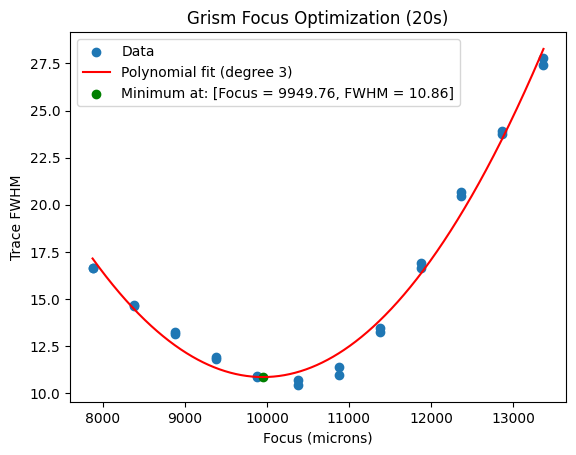

Best Spectral Resolution: FWHM = 10.859174295279445 at Focus = 9949.758834438204


In [97]:
degree = 3
coefficients = np.polyfit(foci_1, widths_1, degree)
polynomial = np.poly1d(coefficients)

def poly_function(x):
    return polynomial(x)

result = minimize(poly_function, x0=np.mean(x))

min_x = result.x[0]
min_y = polynomial(min_x)

x_fit = np.linspace(min(foci_1), max(foci_1), 1000)
y_fit = polynomial(x_fit)

plt.scatter(foci_1, widths_1, label='Data')
plt.plot(x_fit, y_fit, label=f'Polynomial fit (degree {degree})', color='red')
plt.scatter(min_x, min_y, color='green', label=f'Minimum at: [Focus = {min_x:.2f}, FWHM = {min_y:.2f}]')
plt.legend()
plt.xlabel('Focus (microns)')
plt.ylabel('Trace FWHM')
plt.title('Grism Focus Optimization (20s)')
plt.show()

print(f"Best Spectral Resolution: FWHM = {min_y} at Focus = {min_x}")

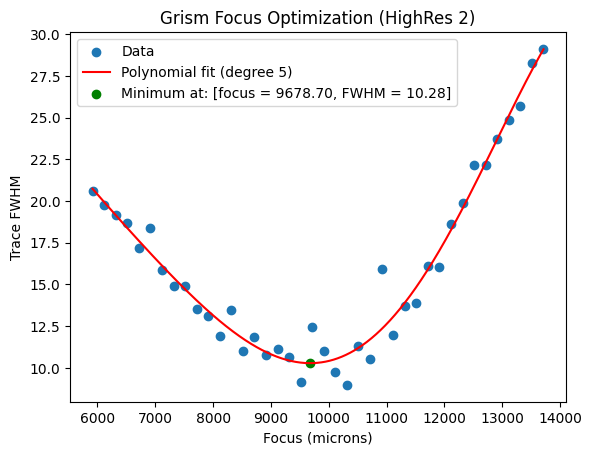

Best Spectral Resolution: FWHM = 10.284614994457826 at Focus = 9678.700930883002


In [233]:
degree = 5
coefficients = np.polyfit(foci_2, widths_2, degree)
polynomial = np.poly1d(coefficients)

def poly_function(x):
    return polynomial(x)

result = minimize(poly_function, x0=np.mean(x))

min_x = result.x[0]
min_y = polynomial(min_x)

x_fit = np.linspace(min(foci_2), max(foci_2), 1000)
y_fit = polynomial(x_fit)

plt.scatter(foci_2, widths_2, label='Data')
plt.plot(x_fit, y_fit, label=f'Polynomial fit (degree {degree})', color='red')
plt.scatter(min_x, min_y, color='green', label=f'Minimum at: [focus = {min_x:.2f}, FWHM = {min_y:.2f}]')
plt.legend()
plt.xlabel('Focus (microns)')
plt.ylabel('Trace FWHM')
plt.title('Grism Focus Optimization (HighRes 2)')
plt.show()

print(f"Best Spectral Resolution: FWHM = {min_y} at Focus = {min_x}")

In [59]:
foci, widths = optimal_focus(img_files)

Analyzing all images in list, this might take a bit...


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

In [94]:
foci = foci_0 + foci_1
widths = widths_0 + widths_1

In [98]:
print(len(foci))

48


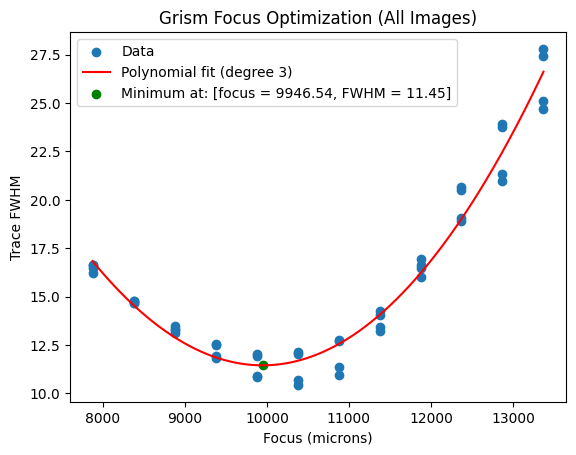

Best Spectral Resolution: FWHM = 11.452970879065788 at Focus = 9946.53625966244


In [95]:
degree = 3
coefficients = np.polyfit(foci, widths, degree)
polynomial = np.poly1d(coefficients)

def poly_function(x):
    return polynomial(x)

result = minimize(poly_function, x0=np.mean(x))

min_x = result.x[0]
min_y = polynomial(min_x)

x_fit = np.linspace(min(foci), max(foci), 1000)
y_fit = polynomial(x_fit)

plt.scatter(foci, widths, label='Data')
plt.plot(x_fit, y_fit, label=f'Polynomial fit (degree {degree})', color='red')
plt.scatter(min_x, min_y, color='green', label=f'Minimum at: [focus = {min_x:.2f}, FWHM = {min_y:.2f}]')
plt.legend()
plt.xlabel('Focus (microns)')
plt.ylabel('Trace FWHM')
plt.title('Grism Focus Optimization (All Images)')
plt.show()

print(f"Best Spectral Resolution: FWHM = {min_y} at Focus = {min_x}")